In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from astropy.stats import sigma_clip
from scipy.stats import binned_statistic

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# So what we are going to do here is start with the Raw Data And Superimpose the Machine Learning work On Top of It #

<span style="color:gray">

- The residual values in the grey data block were corrected for color and stretch. 
- The 

The data that we see in grey is the *raw* data that has been cut for the paper-based
quality cuts and additionally sigma clipped in residual space using Astropy’s
`sigma_clip`:

1. Computes the mean and standard deviation of `y`
2. Flags any point satisfying  
   \[
   |y_i - \bar{y}| > 3\,\sigma_y
   \]
   as an outlier
3. Stops after one iteration (`maxiters = 1`)

</span>


776 SNe before paper-based quality cuts.
579 SNe after paper-based quality cuts.
579 SNe after LOGMSTAR cut.


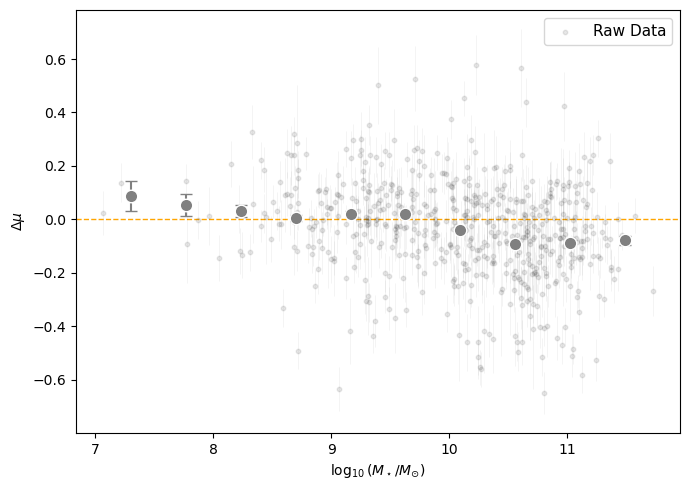

In [23]:
df = pd.read_csv("ZTF_DESI_data/ZTF_snia_DESI_fastspec_hostprops_with_residuals_with_musig.csv")

# -----------------------------------------------------
# DATA FILTER - Paper lccoverage_flag and fitquality_flag
# -------------------------------------------------------
print(len(df), "SNe before paper-based quality cuts.")
df = df[(df["lccoverage_flag"] == 1) & (df["fitquality_flag"] == 1)]
print(len(df), "SNe after paper-based quality cuts.")

# --------------------------------------
# Create g - r host-galaxy color
# --------------------------------------
df["SDSS_g_minus_r"] = df["ABSMAG01_SDSS_G"] - df["ABSMAG01_SDSS_R"]

# Read the Error Collumn for the distance modulus measurements.
yerr_all = df["sigma_mu_meas"]

nbins = 10

# Helper funciton that plots the scatter and error bars. 
# ax - matplotlib axis where the plots will be drawn. 
# mask - the mask that selects which rows to use. 
# xcol - name of the df collumn to put on the x axis. Note residuals are always on the y-axis here.

def scatter_with_errors(ax, mask, xcol, nbins=None):
    # Raw values
    x = df.loc[mask, xcol].values
    y = df.loc[mask, "residual_centered"].values
    yerr = yerr_all.loc[mask].values

    # --- sigma clipping in y (vertical axis) ---
    clipped = sigma_clip(y, sigma=3, maxiters=1)
    mask_clip = ~clipped.mask  # True = keep point

    # apply clipping to x, y, yerr
    x = x[mask_clip]
    y = y[mask_clip]
    yerr = yerr[mask_clip]

    # --- scatter cloud ---
    # Make the raw scatter a bit lighter so the binned trend stands out more.
    ax.scatter(
        x, y,
        alpha=0.12, s=10, color="0.25",
        zorder=1, rasterized=True, label = "Raw Data"
    )

    # --- individual error bars ---
    # Important to note that the way that this function works we will be drawing 
    # an error bar line from y - yerr to y + yerr. Where y_err = sigma_i
    # Make these lighter so they don't overpower the binned points.
    ax.errorbar(
        x, y, yerr=yerr,
        fmt="none",
        ecolor="black",
        elinewidth=0.4,
        alpha=0.08,
        zorder=1,
        capsize=0
    )

    # horizontal reference
    ax.axhline(0, linestyle="--", color="orange", linewidth=1, zorder=0)

    # --- BINNING WITH ERROR PROPAGATION ---
    # NOTE: we set the number of bins here. 

    # binned_statistic is a function tha takes (x, values, ststics, bins, range)
    # x - an array of positions along the x-axis.
    # values - the vaules on which the statistics are computed inside each bin. 
    # NOTE: here we want to just count the number of points in each bin on the 
    # horizontal axis of our plots. Therefore we parse "x" as both the argument and the 
    # value and simply choose "count" as our statistics option. 
    # bin_edges is an array of bin boundaries
    # binnumber - the index for which data point each bin belongs in.
    # This is done mostly becaue the data on the horizontal axis is not ranked so
    # we have to give it an identifier when we do our bin statistics later on. 
    # Bin centers are just calcualted as the middle points between one bin edge and another.
    
    # NOTE: use nbins instead of hard-coding bins=10
    if nbins is None:
        nbins = 10

    _, bin_edges, binnumber = binned_statistic(x, x, statistic="count", bins=nbins) 
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Creating arrays for ht residuals. 
    binned_y = []
    binned_yerr = []

    # Just a fancy way of saying "for each bin"
    # We end up appending the data and error means into
    # an array. 
    for i in range(1, len(bin_edges)):
        in_bin = binnumber == i

        # We end up finding data and errro associated
        # with the number of bin that we are in. 
        y_bin = y[in_bin]
        err_bin = yerr[in_bin]
    
        # inverse-variance weights
        w = 1.0 / (err_bin**2)

        # Avoid divide-by-zero issues if a bin is empty
        if np.sum(in_bin) == 0:
            binned_y.append(np.nan)
            binned_yerr.append(np.nan)
            continue
    
        # weighted mean
        y_mean = np.sum(w * y_bin) / np.sum(w)
    
        # propagated error on the mean
        err_mean = 1.0 / np.sqrt(np.sum(w))
    
        binned_y.append(y_mean)
        binned_yerr.append(err_mean)

    # Plot only the binned points (no connecting trend line)
    binned_y = np.array(binned_y)
    binned_yerr = np.array(binned_yerr)
    ok = np.isfinite(binned_y) & np.isfinite(binned_yerr)

    ax.errorbar(
        bin_centers[ok],
        binned_y[ok],
        yerr=binned_yerr[ok],
        fmt="o",
        color="grey",
        markersize=9,          # Larger binned markers
        capsize=4,             # Slightly smaller caps than 10 for a cleaner look
        markeredgewidth=1.0,
        markeredgecolor="white",
        zorder=5 # Keeps the data looking on top
    )

# **************************************
# --------------------------------------
# Single plot: LOGMSTAR only
# --------------------------------------
# **************************************

fig, ax = plt.subplots(figsize=(7, 5))

# --------------------------------------
# LOGMSTAR
# --------------------------------------

# finite values mask
mask_logm = np.isfinite(df["LOGMSTAR"])
print(np.sum(mask_logm), "SNe after LOGMSTAR cut.")

# Use helper function
scatter_with_errors(ax, mask_logm, "LOGMSTAR", nbins)

# Axis labels
ax.set_xlabel(r"$\log_{10}(M_\star / M_{\odot})$")
ax.set_ylabel(r"$\Delta \mu$")

# --------------------------------------
# Cosmetics
# --------------------------------------

ax.legend(
    loc="best",
    frameon=True,
    fontsize=11
)
fig.tight_layout()
plt.show()